<a href="https://colab.research.google.com/github/vaibhavkatex/The-Internship-2026/blob/main/S19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files
Uploaded = files.upload()

Saving CAR DETAILS FROM CAR DEKHO.csv to CAR DETAILS FROM CAR DEKHO.csv


In [7]:
df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner


In [8]:
df.head(10)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
5,Maruti Alto LX BSIII,2007,140000,125000,Petrol,Individual,Manual,First Owner
6,Hyundai Xcent 1.2 Kappa S,2016,550000,25000,Petrol,Individual,Manual,First Owner
7,Tata Indigo Grand Petrol,2014,240000,60000,Petrol,Individual,Manual,Second Owner
8,Hyundai Creta 1.6 VTVT S,2015,850000,25000,Petrol,Individual,Manual,First Owner
9,Maruti Celerio Green VXI,2017,365000,78000,CNG,Individual,Manual,First Owner


**I chose the **CarDekho Vehicle Dataset** because it contains real-world data about used cars. It includes features such as car name, year, fuel type, transmission, and kilometers driven. The dataset has a continuous target variable called **selling_price**. My goal is to predict the selling price of a used car using machine learning. This dataset is useful for learning data preprocessing, EDA, and regression techniques.
**

In [9]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


In [10]:
df.isnull()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
4335,False,False,False,False,False,False,False,False
4336,False,False,False,False,False,False,False,False
4337,False,False,False,False,False,False,False,False
4338,False,False,False,False,False,False,False,False


In [11]:
missing = df.isnull().sum()

missing_percent = (missing / len(df)) * 100

print(missing_percent)

name             0.0
year             0.0
selling_price    0.0
km_driven        0.0
fuel             0.0
seller_type      0.0
transmission     0.0
owner            0.0
dtype: float64


In [12]:
df.duplicated().sum()

np.int64(763)

In [13]:
df = df.drop_duplicates()

In [14]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.shape

(3577, 8)

In [17]:
df.describe()

,year,selling_price,km_driven
count,3577.000000,3.577000e+03,3577.000000
mean,2012.962538,4.739125e+05,69250.545709
std,4.251759,5.093018e+05,47579.940016
min,1992.000000,2.000000e+04,1.000000
25%,2010.000000,2.000000e+05,36000.000000
50%,2013.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [21]:
# Machine Learning me Target Variable matlab Jo predict karna hai. CarDekho Dataset me generally target hota hai selling_price
print("Minimum :", df["selling_price"].min())
print("Maximum :", df["selling_price"].max())
print("Mean :", df["selling_price"].mean())
print("Median :", df["selling_price"].median())

Minimum : 20000
Maximum : 8900000
Mean : 473912.54207436397
Median : 350000.0


1 . The average (mean) selling price is 473912.54207436397

2 . The minimum and maximum selling prices show the overall price range in the dataset.

3 . If the mean is higher than the median, the data is positively (right) skewed due to a few expensive cars.

4 . A large difference between the maximum value and the 75th percentile suggests the presence of outliers.

Numeric Columns:
Index(['year', 'selling_price', 'km_driven'], dtype='object')


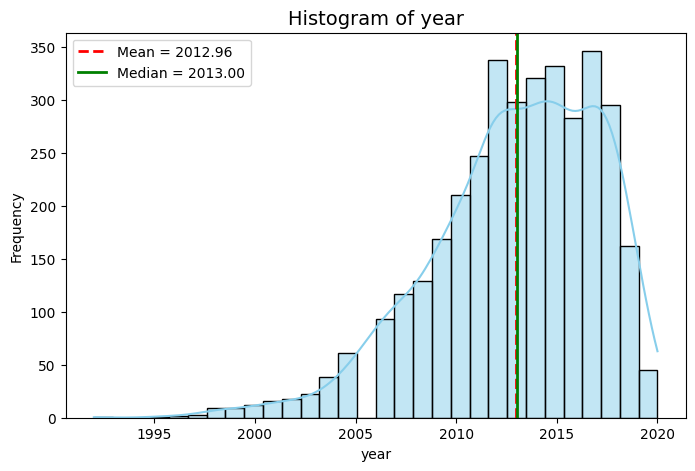

Column : year
Minimum : 1992
Maximum : 2020
Mean    : 2012.96
Median  : 2013.00
Std Dev : 4.25


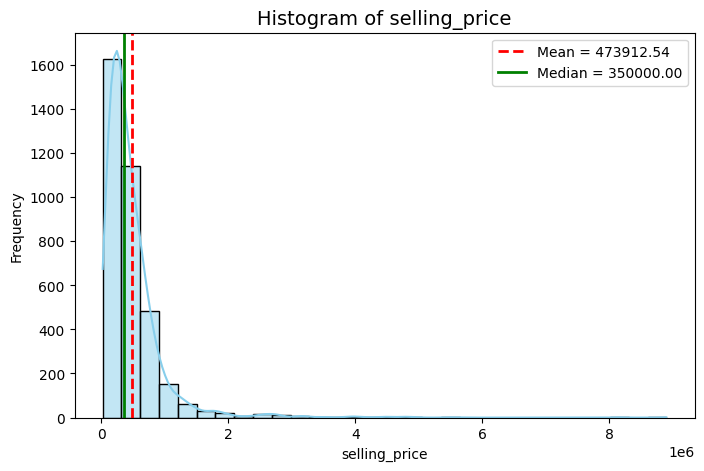

Column : selling_price
Minimum : 20000
Maximum : 8900000
Mean    : 473912.54
Median  : 350000.00
Std Dev : 509301.81


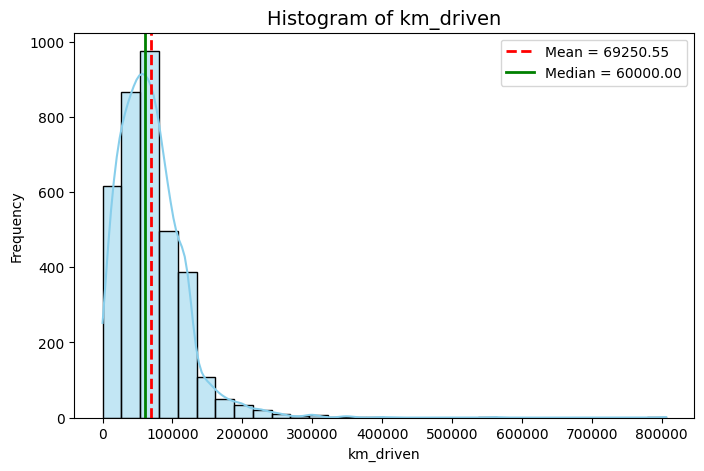

Column : km_driven
Minimum : 1
Maximum : 806599
Mean    : 69250.55
Median  : 60000.00
Std Dev : 47579.94


In [25]:
# Select all numeric columns
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

print("Numeric Columns:")
print(numeric_columns)

# Loop through each numeric column
for col in numeric_columns:

    plt.figure(figsize=(8,5))

    # Histogram
    sns.histplot(df[col], bins=30, kde=True, color='skyblue')

    # Mean Line
    plt.axvline(df[col].mean(),
                color='red',
                linestyle='--',
                linewidth=2,
                label=f"Mean = {df[col].mean():.2f}")

    # Median Line
    plt.axvline(df[col].median(),
                color='green',
                linestyle='-',
                linewidth=2,
                label=f"Median = {df[col].median():.2f}")

    plt.title(f"Histogram of {col}", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()

    plt.show()

    # Print Summary
    print("="*60)
    print(f"Column : {col}")
    print(f"Minimum : {df[col].min()}")
    print(f"Maximum : {df[col].max()}")
    print(f"Mean    : {df[col].mean():.2f}")
    print(f"Median  : {df[col].median():.2f}")
    print(f"Std Dev : {df[col].std():.2f}")
    print("="*60)

Index(['name', 'fuel', 'seller_type', 'transmission', 'owner'], dtype='object')


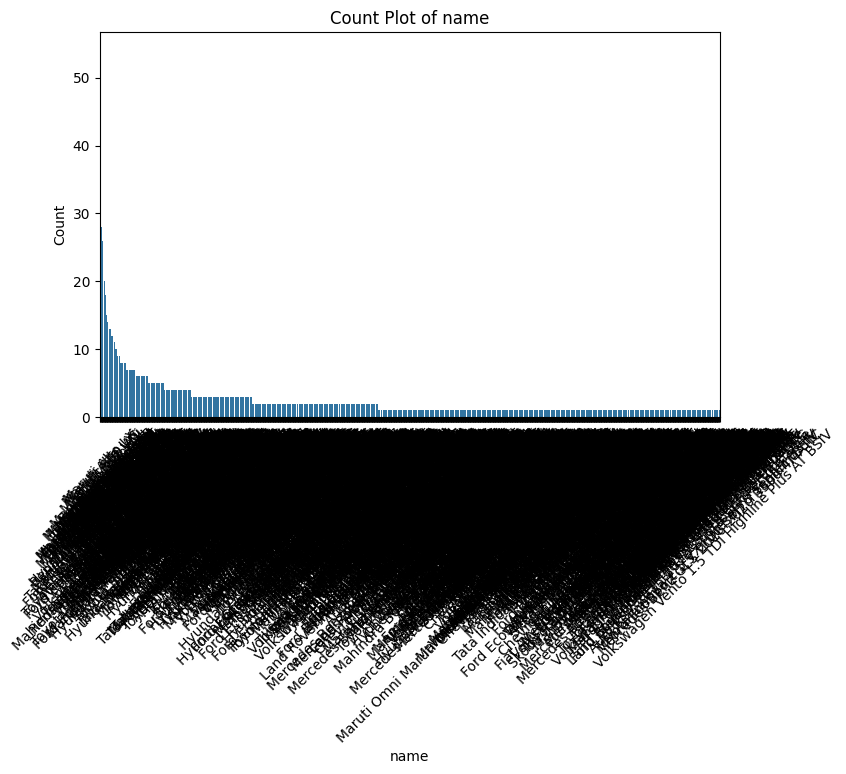

Column : name
name
Maruti Swift Dzire VDI        54
Maruti Alto 800 LXI           48
Maruti Alto LXi               42
Maruti Alto LX                30
Maruti Swift VDI BSIV         28
                              ..
Tata Indica V2 DLS BSII        1
Mahindra XUV500 W10 AWD        1
Toyota Fortuner 2.7 2WD AT     1
Fiat Punto EVO 1.3 Emotion     1
Nissan Terrano XE 85 PS        1
Name: count, Length: 1491, dtype: int64


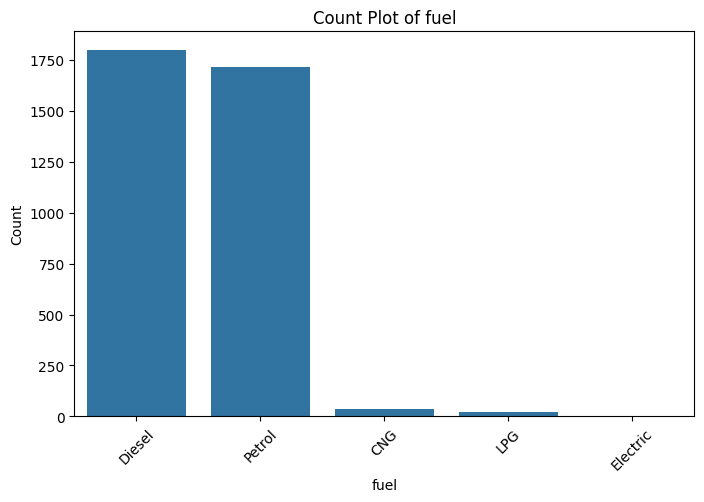

Column : fuel
fuel
Diesel      1800
Petrol      1717
CNG           37
LPG           22
Electric       1
Name: count, dtype: int64


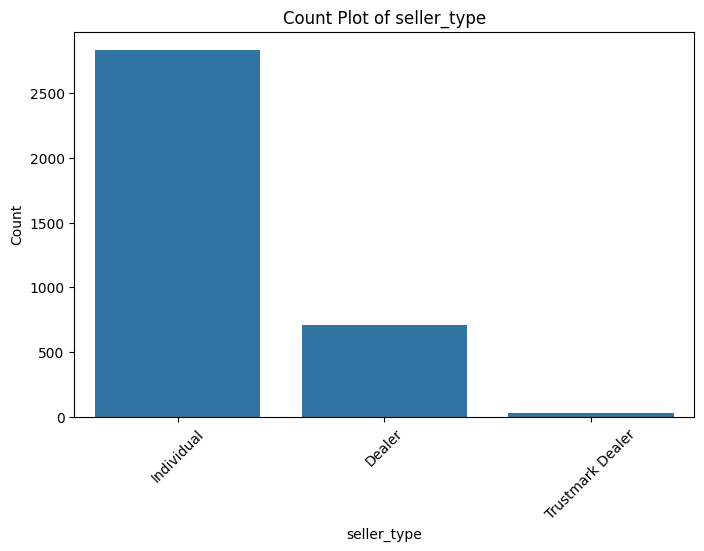

Column : seller_type
seller_type
Individual          2832
Dealer               712
Trustmark Dealer      33
Name: count, dtype: int64


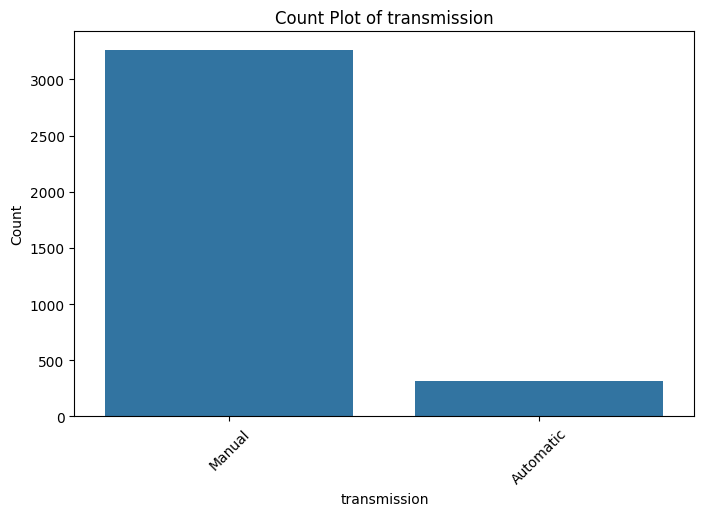

Column : transmission
transmission
Manual       3265
Automatic     312
Name: count, dtype: int64


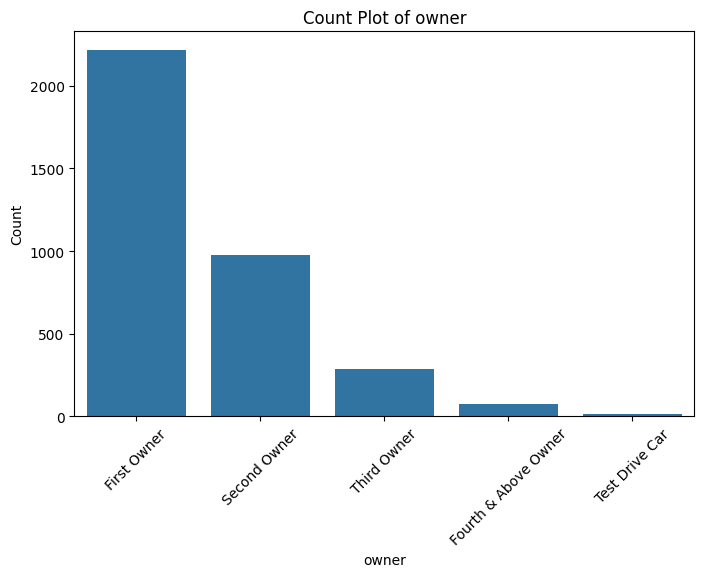

Column : owner
owner
First Owner             2218
Second Owner             978
Third Owner              289
Fourth & Above Owner      75
Test Drive Car            17
Name: count, dtype: int64


In [27]:


# Select categorical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns


print(categorical_columns)

# Loop through each categorical column
for col in categorical_columns:

    plt.figure(figsize=(8,5))

    sns.countplot(data=df,x=col,order=df[col].value_counts().index)

    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.xticks(rotation=45)

    plt.show()

    # Print value counts
    print("="*60)
    print(f"Column : {col}")
    print(df[col].value_counts())
    print("="*60)

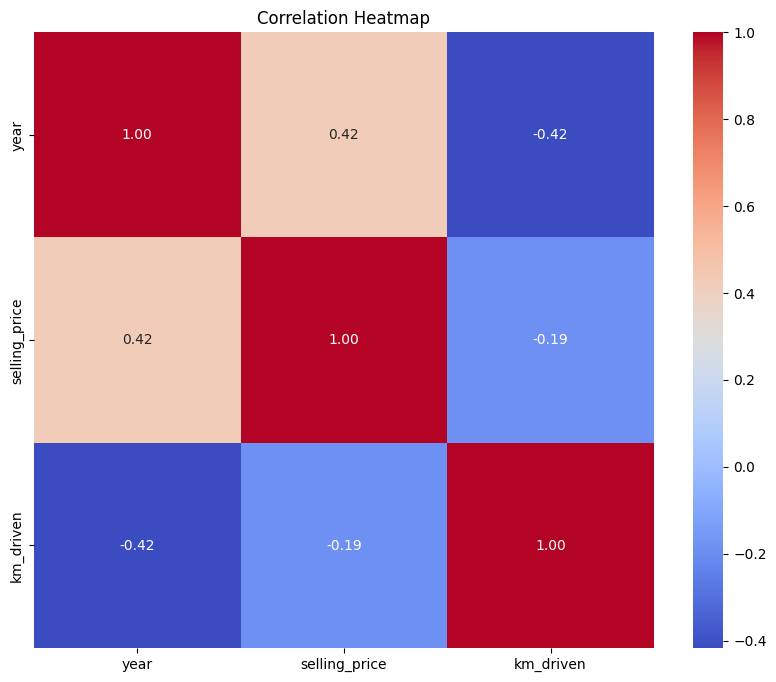

In [31]:

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(correlation_matrix,cmap='coolwarm',fmt='.2f',annot=True)

plt.title("Correlation Heatmap")
plt.show()

**The target variable selected is selling_price because it is a continuous numerical variable that represents the value of a vehicle. The objective of the machine learning model is to predict the selling price using vehicle-related features such as year, fuel type, engine size, mileage, transmission, and kilometers driven. Since the target is continuous, this is a Regression Problem.**

In [33]:
target = "selling_price"

# Independent Features
X = df.drop(columns=["selling_price"])

# Dependent Feature
y = df[target]

print("Independent Features (X):")
print(X.columns)

print("\nDependent Feature (y):")
print(y.name)

Independent Features (X):
Index(['name', 'year', 'km_driven', 'fuel', 'seller_type', 'transmission',
       'owner'],
      dtype='object')

Dependent Feature (y):
selling_price


**One-Hot Encoding converts categorical variables into binary numeric columns so that machine learning algorithms can process them. It avoids assigning false numerical order to categories such as Petrol, Diesel, and CNG. Using drop_first=True also helps avoid the Dummy Variable Trap by removing redundant columns.**

In [34]:


# Select categorical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

print("Categorical Columns:")
print(categorical_columns)

# Before Encoding (show first 5 rows)
print("\nBefore Encoding:")
print(df[categorical_columns].head())

# One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

# After Encoding (show first 5 rows)
print("\nAfter Encoding:")
print(df_encoded.head())

# Shape Comparison
print("\nOriginal Shape:", df.shape)
print("Encoded Shape :", df_encoded.shape)

Categorical Columns:
Index(['name', 'fuel', 'seller_type', 'transmission', 'owner'], dtype='object')

Before Encoding:
                       name    fuel seller_type transmission         owner
0             Maruti 800 AC  Petrol  Individual       Manual   First Owner
1  Maruti Wagon R LXI Minor  Petrol  Individual       Manual   First Owner
2      Hyundai Verna 1.6 SX  Diesel  Individual       Manual   First Owner
3    Datsun RediGO T Option  Petrol  Individual       Manual   First Owner
4     Honda Amaze VX i-DTEC  Diesel  Individual       Manual  Second Owner

After Encoding:
   year  selling_price  km_driven  name_Ambassador Classic 2000 Dsz  \
0  2007          60000      70000                             False   
1  2007         135000      50000                             False   
2  2012         600000     100000                             False   
3  2017         250000      46000                             False   
4  2014         450000     141000                          

**Standard Scaling was applied to all independent features using StandardScaler. This technique transforms each feature so that it has a mean of 0 and a standard deviation of 1. Scaling helps machine learning algorithms perform better by ensuring that features with larger numerical values do not dominate those with smaller values.**

In [35]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Independent Features (X)
X = df_encoded.drop("selling_price", axis=1)

# Target Variable (y)
y = df_encoded["selling_price"]

# Create StandardScaler object
scaler = StandardScaler()

# Apply Scaling
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# First 5 rows
print(X_scaled.head())

       year  km_driven  name_Ambassador Classic 2000 Dsz  \
0 -1.402566   0.015754                         -0.016723   
1 -1.402566  -0.404650                         -0.016723   
2 -0.226418   0.646360                         -0.016723   
3  0.949731  -0.488731                         -0.016723   
4  0.244042   1.508188                         -0.016723   

   name_Ambassador Grand 1800 ISZ MPFI PW CL  name_Audi A4 1.8 TFSI  \
0                                  -0.016723              -0.016723   
1                                  -0.016723              -0.016723   
2                                  -0.016723              -0.016723   
3                                  -0.016723              -0.016723   
4                                  -0.016723              -0.016723   

   name_Audi A4 2.0 TDI  name_Audi A4 2.0 TDI 177 Bhp Premium Plus  \
0             -0.016723                                  -0.016723   
1             -0.016723                                  -0.016723   
2 